In [1]:
# Dont delete this - this is necessary to run it on colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  %cd /content/drive/MyDrive/Python Code/Paper-condensed/scripts/
else:
  %cd /Users/sagefox/My Drive (sagefox@uw.edu)/Research/Python_Code/Paper-condensed/scripts/

[WinError 3] The system cannot find the path specified: '/Users/sagefox/My Drive (sagefox@uw.edu)/Research/Python_Code/Paper-condensed/scripts/'
C:\Users\foxni\Documents\NWP_Land_Sea_Fluxes\scripts


In [2]:
# Adapted from code from Sage

########## PUBLICATION VERSION #########

import pandas as pd
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.collections import LineCollection
from load_rivers import *  # This brings in raw_chem_dfs

C:\Users\foxni\Documents\NWP_Land_Sea_Fluxes\scripts\load_rivers.py:109: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('b.d.', 0.0, inplace=True)


In [5]:
# ===== USER-SET PARAMETERS =====
savefig = True
add_chem_points = True
use_rolling = False         # Toggle: if True, contemporary flow is computed with a two-sided 7-day rolling average
rolling_window = 7          # Window size for rolling average if toggled on
figpath = Path("../results")
datapath = Path("../data/Downstream_Estimate_All_Rivers_rolling60.csv")

# Toggle for uniform sampling point symbols:
# If True, all points will be plotted as uniform navy circles.
# If False, points will be plotted with team-coded markers.
uniform_points = True

# Toggle for displaying the legend for chemistry sampling points.
# Set to False to suppress the points legend.
display_points_legend = False

# Toggle for displaying the legend for the streamflow data (lines and shading).
display_data_legend = True

# Toggle for displaying a separate legend (colorbar) for the streamflow data line.
display_line_colorbar = True

# Toggle for coloring the daily mean line by its percentile relative to the historical record.
color_line_by_percentile = True

# Toggle for date range option:
# "none"       => each river uses its own sampling period,
# "max"        => all plots use the maximum shared sampling period,
# "water_year" => all plots use April 1, 2022 through April 1, 2023.
date_range_option = "water_year"  # Options: "none", "max", "water_year"

In [9]:
data.dropna(how="any").index

DatetimeIndex(['2002-04-10', '2002-04-11', '2002-04-12', '2002-04-13',
               '2002-04-14', '2002-04-15', '2002-04-16', '2002-04-17',
               '2002-04-18', '2002-04-19',
               ...
               '2024-01-22', '2024-01-23', '2024-01-24', '2024-01-25',
               '2024-01-26', '2024-01-27', '2024-01-28', '2024-01-29',
               '2024-01-30', '2024-01-31'],
              dtype='datetime64[ns]', name='Date', length=7962, freq=None)

C:\Users\foxni\AppData\Local\Temp\ipykernel_62456\801549971.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.05, 0.05, 1, 0.95])


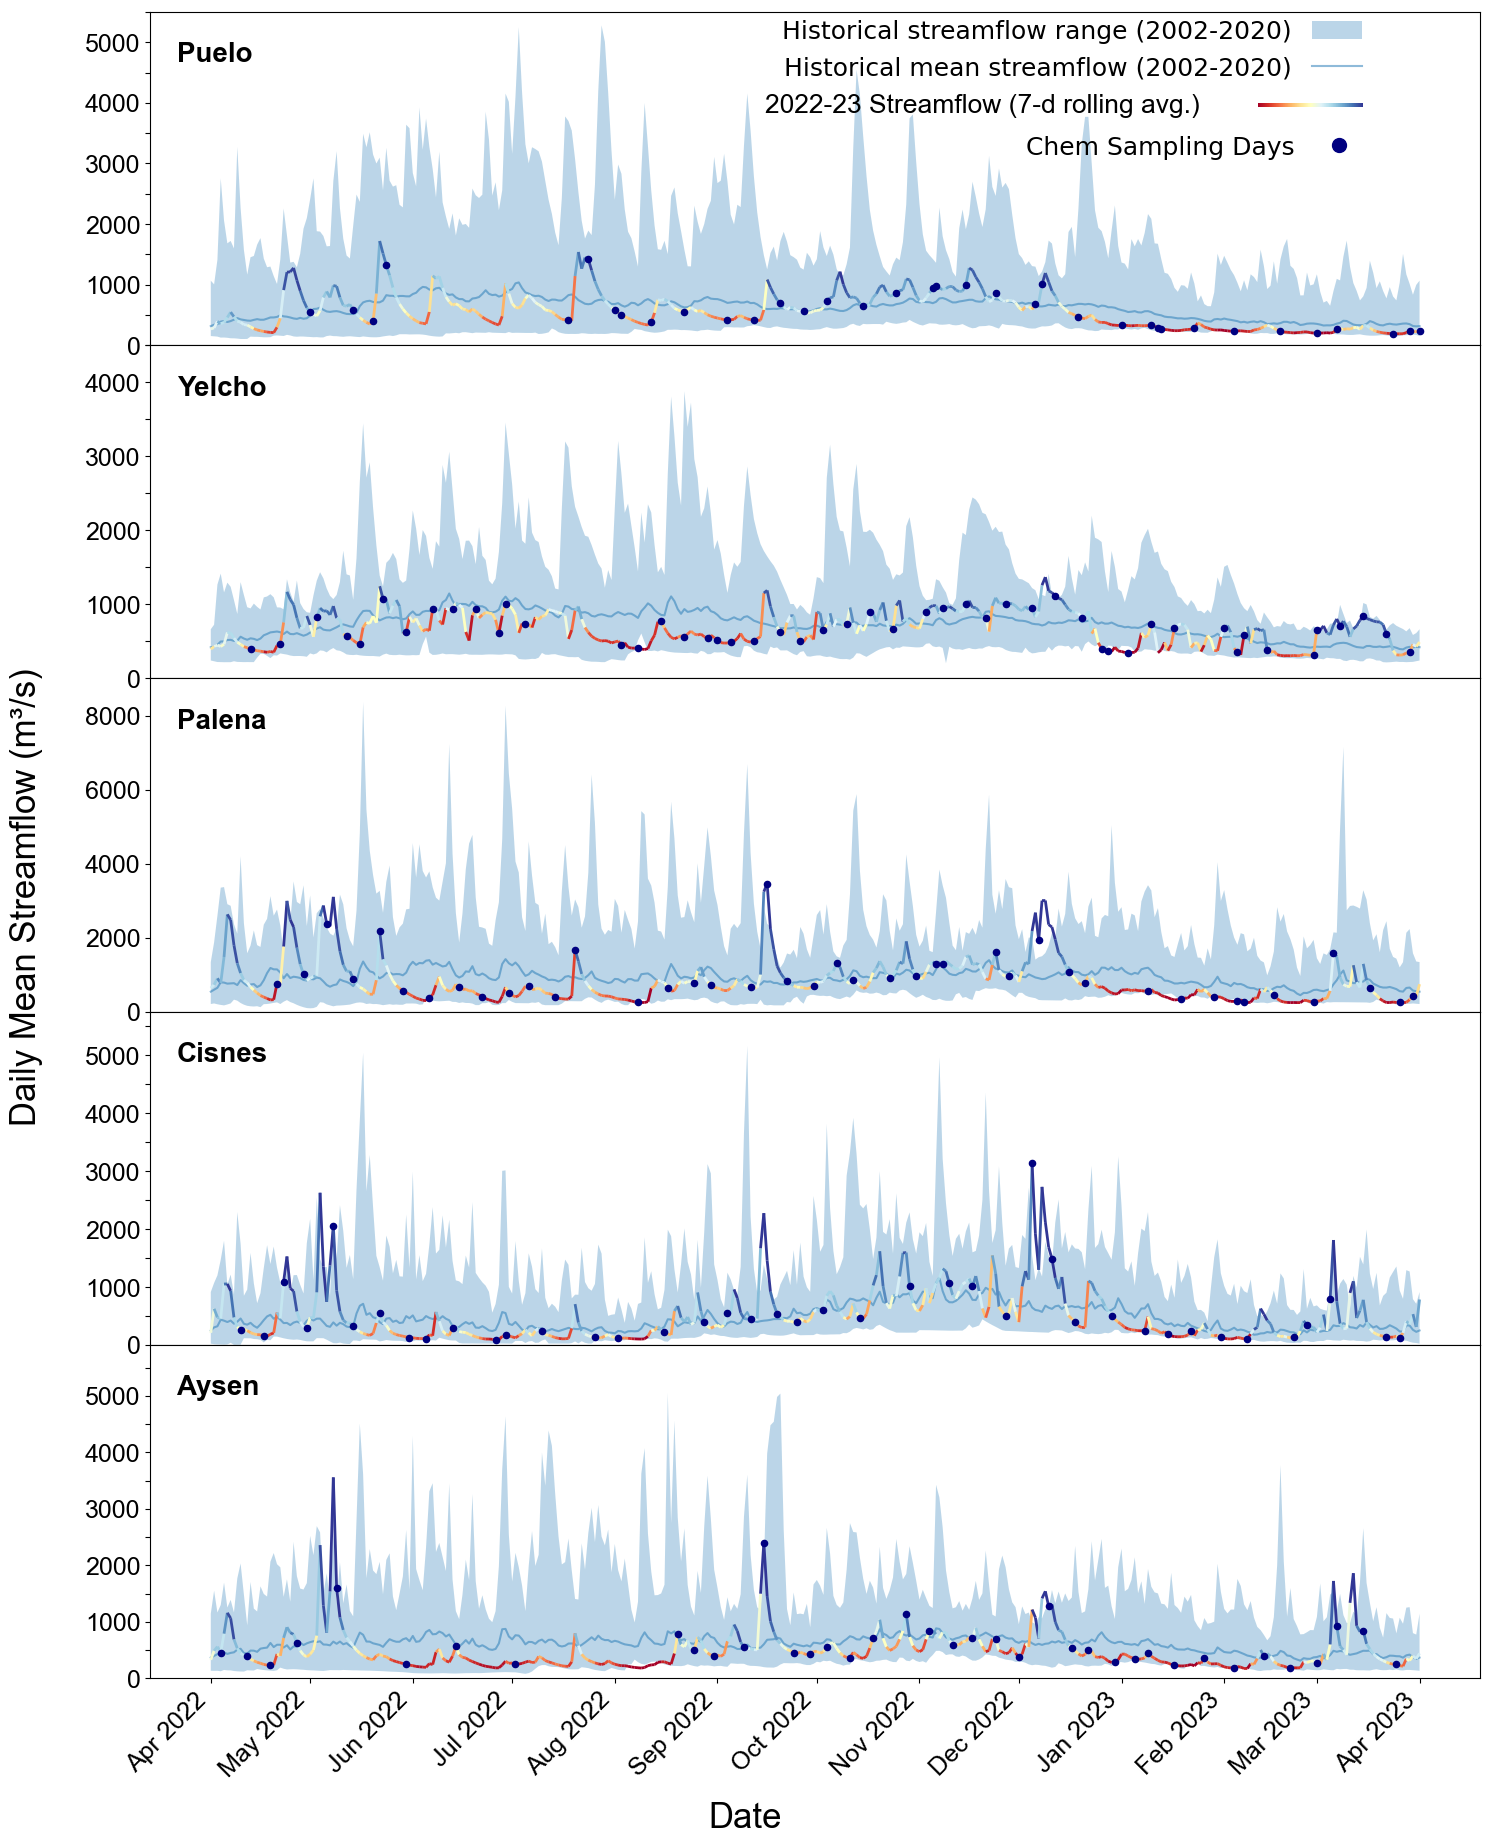

In [7]:
fname_stem = "sampled_hydrograph_"
if display_points_legend:
    fname_stem = fname_stem + "legend_on"
if display_line_colorbar:
    fname_stem = fname_stem + "linecolorbar"
if uniform_points:
    fname_stem = fname_stem + "uniform_points"
else:
    fname_stem = fname_stem + "coded_points"

# ===== LOAD NEW STREAMFLOW DATA (CSV) =====
data = pd.read_csv(datapath, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# The CSV has columns for each river (with headers: Puelo, Yelcho, Palena, Cisnes, Aysen)
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary of the entire (all available) flow series for each river.
all_flow = {name: data[code] for (name, code) in zip(river_names, river_codes)}

# ===== DETERMINE COMMON DATE RANGE (if merging x-axes) =====
if date_range_option in ["max", "water_year"]:
    if date_range_option == "max":
        # Use the latest start and the earliest end among the chemistry sampling records.
        sample_starts = [raw_chem_dfs[name].index.min() for name in river_names]
        sample_ends = [raw_chem_dfs[name].index.max() for name in river_names]
        common_start = max(sample_starts)
        common_end = min(sample_ends)
    elif date_range_option == "water_year":
        common_start = pd.Timestamp("2022-04-01")
        common_end = pd.Timestamp("2023-04-01")

# ===== DEFINE FUNCTIONS =====
def agg_historical_flow(historical, contextualize=None):
    """
    Compute daily (by day-of-year) min, max, and mean for the historical flow series.
    Then, if contextualize is provided, re-index the aggregated stats so that they
    align with the dates in the contemporary (sampled) period.
    """
    gb = historical.groupby(historical.index.dayofyear)
    stats_HDF = gb.agg(['min', 'max', 'mean'])
    if contextualize is not None:
        stats_HDF = pd.DataFrame(
            contextualize.index.dayofyear.map(lambda a: stats_HDF.loc[a]).to_list()
        )
        stats_HDF.index = contextualize.index
        stats_HDF.columns = ["min", "max", "mean"]
    return stats_HDF

# ===== PREPARE CONTEMPORARY AND HISTORIC STREAMFLOW =====
contemporary_flow = dict()
historic_flow = dict()
for name in river_names:
    if date_range_option == "none":
        sample_start = raw_chem_dfs[name].index.min()
        sample_end = raw_chem_dfs[name].index.max()
    else:
        sample_start = common_start
        sample_end = common_end
    # Extract contemporary flow: data from the CSV within the sampling period.
    cont = all_flow[name].loc[sample_start:sample_end]
    if use_rolling:
        cont = cont.rolling(window=rolling_window, center=True).mean()
    contemporary_flow[name] = cont
    # Extract historical flow: all data strictly before the first sampling date.
    hist = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))]
    historic_flow[name] = hist

# Compute aggregated historical statistics for each river,
# contextualized to the contemporary dates.
agg_HDF = {name: agg_historical_flow(historic_flow[name], contextualize=contemporary_flow[name])
           for name in river_names}

# ===== PREPARE CHEMISTRY SAMPLING POINTS =====
if add_chem_points:
    import matplotlib.lines as mlines
    sampling_points = dict()
    for (name, df) in raw_chem_dfs.items():
        sp = df.reset_index()[["Date", "Team"]].drop_duplicates("Date").set_index("Date")
        # Define markers: LOCAL gets '^'; missing or NaN values get 'o'; all others default to 'R'
        sp["Marker"] = sp["Team"].map({"LOCAL": "^", float("NaN"): "o"}).fillna("R")
        # Identify which sampling dates are in the contemporary period.
        sp["on_line"] = sp.index.isin(contemporary_flow[name].index)
        # For the Y-value, use the contemporary flow (re-indexed using nearest available value)
        sp["Y"] = contemporary_flow[name].reindex(sp.index, method='nearest')
        sampling_points[name] = sp
    # Create custom legend markers for the chemistry sampling points.
    lines1 = (
        mlines.Line2D([], [], color="#b33dc6", marker="s", linestyle='None', markersize=10, label="Community"),
        mlines.Line2D([], [], color="#27aeef", marker="^", linestyle='None', markersize=10, label="Unknown"),
        mlines.Line2D([], [], color="#ea5545", marker="o", linestyle='None', markersize=10, label="CIEP")
    )

# ===== PREPARE HISTORICAL DATA BY DAY-OF-YEAR FOR PERCENTILE CALCULATION =====
# For each river, group the historical flow by day-of-year.
historical_percentile_dict = {}
for name in river_names:
    historical_data = historic_flow[name]
    grouped = historical_data.groupby(historical_data.index.dayofyear)
    historical_percentile_dict[name] = {day: group.dropna().values for day, group in grouped}

# ===== PLOTTING =====
# Create subplots. If merging x-axes, use sharex=True and hide x-axis labels on all but the bottom panel.
if date_range_option == "none":
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 4*5), gridspec_kw={'hspace': 0.5})
else:
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 4*5), sharex=True, gridspec_kw={'hspace': 0})
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

# Define a date formatter for the x-axis.
date_formatter = mdates.DateFormatter('%b %Y')

# Choose colormap and normalization for the colored line.
cmap = plt.get_cmap('RdYlBu')
norm = plt.Normalize(0, 100)

for (name, ax) in zip(river_names, axes):
    # Aggregated historical stats and contemporary flow.
    HDF = agg_HDF[name]
    daily_flow_ser = contemporary_flow[name]

    # Plot the historical min/max as a shaded area and historical mean as a line.
    ax.fill_between(HDF.index, HDF["min"], HDF["max"], alpha=0.3, label="Historical streamflow range (2002-2020)")
    ax.plot(HDF.index, HDF["mean"], label="Historical mean streamflow (2002-2020)", alpha=0.5)

    # Plot the daily mean line.
    if color_line_by_percentile:
        # Compute percentiles for each value in the contemporary series.
        percentiles = []
        for dt, value in daily_flow_ser.items():
            day = dt.timetuple().tm_yday
            hist_vals = historical_percentile_dict[name].get(day, np.array([np.nan]))
            if len(hist_vals) > 0:
                p = np.sum(hist_vals <= value) / len(hist_vals) * 100
            else:
                p = 50  # default if no historical data available
            percentiles.append(p)
        percentiles = np.array(percentiles)

        # Convert dates to numerical format for LineCollection.
        x = mdates.date2num(daily_flow_ser.index.to_pydatetime())
        y = daily_flow_ser.values
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        # Use the percentile at the start of each segment.
        lc.set_array(percentiles[:-1])
        lc.set_linewidth(2)
        line = ax.add_collection(lc)
    else:
        ax.plot(daily_flow_ser.index, daily_flow_ser, label="Daily mean")

    # Plot chemistry sampling points.
    if add_chem_points:
        sd_df = sampling_points[name].reset_index()
        # Trim sampling points to the common date range when merging x-axes.
        if date_range_option != "none":
            sd_df = sd_df[(sd_df["Date"] >= common_start) & (sd_df["Date"] <= common_end)]
        if uniform_points:
            sd_df.plot.scatter("Date", "Y", marker="o", s=20, ax=ax, color="navy", zorder=10)
        else:
            sd_df[sd_df["Marker"] == "R"].plot.scatter("Date", "Y", marker="s", s=20, ax=ax, color="#b33dc6", zorder=10)
            sd_df[sd_df["Marker"] == "^"].plot.scatter("Date", "Y", marker="^", s=20, ax=ax, color="#27aeef", zorder=10)
            sd_df[sd_df["Marker"] == "o"].plot.scatter("Date", "Y", marker="o", s=20, ax=ax, color="#ea5545", zorder=10)

    # Set individual subplot labels.
    if date_range_option == "none":
        ax.set_ylabel("Flow (m³/s)")
        ax.set_xlabel("Date")
        ax.set_title(name)
    else:
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.text(0.02, 0.85, name, transform=ax.transAxes, fontsize=20, fontname="Arial", fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.xaxis.set_major_formatter(date_formatter)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Set font properties for tick labels.
    for label in ax.get_xticklabels():
        label.set_fontsize(18)
        label.set_fontname('Arial')
    for label in ax.get_yticklabels():
        label.set_fontsize(18)
        label.set_fontname('Arial')

    # Turn off minor ticks.
    ax.minorticks_off()

    # --- Set y-axis ticks and limits in merged mode individually.
    if date_range_option != "none":
        if name == "Palena":
            ax.set_ylim(0, 9000)
            ax.yaxis.set_major_locator(MultipleLocator(2000))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 2000, 0, atol=1e-6) else ""))
        elif name == "Yelcho":
            ax.set_ylim(0, 4500)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))
        elif name == "Cisnes":
            ax.set_ylim(0, 5750)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))
        elif name == "Aysen":
            ax.set_ylim(0, 5900)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))
        else:
            data_max = max(daily_flow_ser.max(), HDF["max"].max())
            upper_lim = np.ceil(data_max / 500) * 500
            ax.set_ylim(0, upper_lim)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))

    # Set shared x-axis tick marks to be exactly one per month.
    if date_range_option != "none":
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Add common x- and y-axis labels if the subplots are merged.
if date_range_option != "none":
    fig.text(0.5, 0.035, "Date", ha="center", fontsize=25, fontname="Arial")
    fig.text(0.01, 0.5, "Daily Mean Streamflow (m³/s)", va="center", rotation="vertical", fontsize=25, fontname="Arial")

# Add a figure-level legend for the streamflow data if desired.
if display_data_legend and display_points_legend:
    data_handles = [axes[0].collections[0]] + axes[0].lines[:]
    fig.legend(handles=data_handles, loc='upper left', bbox_to_anchor=(0.55, 0.95), fontsize=18, frameon=False)

if color_line_by_percentile and display_line_colorbar and display_points_legend:
    # cbar = fig.colorbar(lc, ax=axes, orientation='horizontal', fraction=0.02, pad=0.02)
    # cbar.set_label("Percentile", fontsize=18, fontname="Georgia")
    cax = fig.add_axes([0.55, 0.895, 0.1, 0.002])  # [left, bottom, width, height]
    cbar = fig.colorbar(lc, cax=cax, orientation='horizontal')
    #cbar.set_label("Percentile", fontsize=18, fontname="Georgia")
    # Remove the colorbar frame (borders) and tick marks.
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(axis='both', which='both', length=0)  # remove tick marks
    #cbar.ax.set_yticklabels([])  # remove tick labels
    cbar.ax.set_xticklabels([])
    # Remove the default label (if any) and add an annotation to position it on the right.
    cax.annotate("Sampled Streamflow", xy=(1.12, 0.5), xycoords="axes fraction",
                 rotation=0, va="center", fontsize=19, fontname="Arial")

####Conditional formatting for no points legend
# --- New block: Adjust legends if using uniform points and no points legend
if uniform_points and display_data_legend and (not display_points_legend):
    # Remove any existing figure-level legend for data (if needed)
    # (This depends on your earlier code; if you already have one, this block will override its placement.)
    data_handles = [axes[0].collections[0]] + axes[0].lines[:]
    # Shift the data legend to the right.
    fig.legend(handles=data_handles, loc='upper left', bbox_to_anchor=(0.51, 0.95), fontsize=18, frameon=False, markerfirst=False)

    # Adjust the colorbar position: add a new colorbar axes positioned further to the right.
    # (Assuming lc is defined in your loop for the colored line.)
    cax = fig.add_axes([0.842, 0.895, 0.07, 0.002])  # [left, bottom, width, height] in figure coords
    cbar = fig.colorbar(lc, cax=cax, orientation='horizontal')
    #cbar.ax.invert_xaxis()
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(axis='both', which='both', length=0)
    cbar.ax.set_xticklabels([])
    cax.annotate("2022-23 Streamflow (7-d rolling avg.)", xy=(-4.7, 0.5), xycoords="axes fraction",
                 rotation=0, va="center", fontsize=19, fontname="Arial")

    # Create a new axes for the uniform points legend.
    up_ax = fig.add_axes([0.75, 0.85, 0.1, 0.05])  # Adjust these coordinates as needed.
    up_ax.axis('off')
    from matplotlib.lines import Line2D
    up_handle = Line2D([], [], marker='o', color='navy', linestyle='None', markersize=10, label="Chem Sampling Days")
    up_ax.legend(handles=[up_handle], loc='center', frameon=False, fontsize=18, markerfirst=False)
# #### end conditional block

# Add a figure-level legend for the sampling points if desired.
if display_points_legend:
    fig.legend(handles=lines1, loc='upper right', bbox_to_anchor=(0.98, 0.95), fontsize=18, frameon=False)

fig.tight_layout(rect=[0.05, 0.05, 1, 0.95])
if savefig:
    plt.savefig(figpath/(fname_stem+"_"+date_range_option+"_pub.jpeg"), dpi=800, bbox_inches='tight')
plt.show()


In [ ]:
fname_stem = "sampled_hydrograph"
if display_points_legend:
    fname_stem = fname_stem + "_legend_on"
if display_line_colorbar:
    fname_stem = fname_stem + "_linecolorbar"
if uniform_points:
    fname_stem = fname_stem + "_uniform_points"
else:
    fname_stem = fname_stem + "_coded_points"

# ===== LOAD NEW STREAMFLOW DATA (CSV) =====
data = pd.read_csv(datapath, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# The CSV has columns for each river (with headers: Puelo, Yelcho, Palena, Cisnes, Aysen)
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary of the entire (all available) flow series for each river.
all_flow = {name: data[code] for (name, code) in zip(river_names, river_codes)}

# ===== DETERMINE COMMON DATE RANGE (if merging x-axes) =====
if date_range_option in ["max", "water_year"]:
    if date_range_option == "max":
        # Use the latest start and the earliest end among the chemistry sampling records.
        sample_starts = [raw_chem_dfs[name].index.min() for name in river_names]
        sample_ends = [raw_chem_dfs[name].index.max() for name in river_names]
        common_start = max(sample_starts)
        common_end = min(sample_ends)
    elif date_range_option == "water_year":
        common_start = pd.Timestamp("2022-04-01")
        common_end = pd.Timestamp("2023-04-01")

# ===== DEFINE FUNCTIONS =====
def agg_historical_flow(historical, contextualize=None):
    """
    Compute daily (by day-of-year) min, max, and mean for the historical flow series.
    Then, if contextualize is provided, re-index the aggregated stats so that they
    align with the dates in the contemporary (sampled) period.
    """
    gb = historical.groupby(historical.index.dayofyear)
    stats_HDF = gb.agg(['min', 'max', 'mean'])
    if contextualize is not None:
        stats_HDF = pd.DataFrame(
            contextualize.index.dayofyear.map(lambda a: stats_HDF.loc[a]).to_list()
        )
        stats_HDF.index = contextualize.index
        stats_HDF.columns = ["min", "max", "mean"]
    return stats_HDF

# ===== PREPARE CONTEMPORARY AND HISTORIC STREAMFLOW =====
contemporary_flow = dict()
historic_flow = dict()
for name in river_names:
    if date_range_option == "none":
        sample_start = raw_chem_dfs[name].index.min()
        sample_end = raw_chem_dfs[name].index.max()
    else:
        sample_start = common_start
        sample_end = common_end
    # Extract contemporary flow: data from the CSV within the sampling period.
    cont = all_flow[name].loc[sample_start:sample_end]
    if use_rolling:
        cont = cont.rolling(window=rolling_window, center=True).mean()
    contemporary_flow[name] = cont
    # Extract historical flow: all data strictly before the first sampling date.
    hist = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))]
    historic_flow[name] = hist

# Compute aggregated historical statistics for each river,
# contextualized to the contemporary dates.
agg_HDF = {name: agg_historical_flow(historic_flow[name], contextualize=contemporary_flow[name])
           for name in river_names}

# ===== PREPARE CHEMISTRY SAMPLING POINTS =====
if add_chem_points:
    import matplotlib.lines as mlines
    sampling_points = dict()
    for (name, df) in raw_chem_dfs.items():
        sp = df.reset_index()[["Date", "Team"]].drop_duplicates("Date").set_index("Date")
        # Define markers: LOCAL gets '^'; missing or NaN values get 'o'; all others default to 'R'
        sp["Marker"] = sp["Team"].map({"LOCAL": "^", float("NaN"): "o"}).fillna("R")
        # Identify which sampling dates are in the contemporary period.
        sp["on_line"] = sp.index.isin(contemporary_flow[name].index)
        # For the Y-value, use the contemporary flow (re-indexed using nearest available value)
        sp["Y"] = contemporary_flow[name].reindex(sp.index, method='nearest')
        sampling_points[name] = sp
    # Create custom legend markers for the chemistry sampling points.
    lines1 = (
        mlines.Line2D([], [], color="#b33dc6", marker="s", linestyle='None', markersize=10, label="Community"),
        mlines.Line2D([], [], color="#27aeef", marker="^", linestyle='None', markersize=10, label="Unknown"),
        mlines.Line2D([], [], color="#ea5545", marker="o", linestyle='None', markersize=10, label="CIEP")
    )

# ===== PREPARE HISTORICAL DATA BY DAY-OF-YEAR FOR PERCENTILE CALCULATION =====
# For each river, group the historical flow by day-of-year.
historical_percentile_dict = {}
for name in river_names:
    historical_data = historic_flow[name]
    grouped = historical_data.groupby(historical_data.index.dayofyear)
    historical_percentile_dict[name] = {day: group.dropna().values for day, group in grouped}

# ===== PLOTTING =====
# Create subplots. If merging x-axes, use sharex=True and hide x-axis labels on all but the bottom panel.
if date_range_option == "none":
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 4*5), gridspec_kw={'hspace': 0.5})
else:
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 4*5), sharex=True, gridspec_kw={'hspace': 0})
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

# Define a date formatter for the x-axis.
date_formatter = mdates.DateFormatter('%b %Y')

# Choose colormap and normalization for the colored line.
cmap = plt.get_cmap('RdYlBu')
norm = plt.Normalize(0, 100)

for (name, ax) in zip(river_names, axes):
    # Aggregated historical stats and contemporary flow.
    HDF = agg_HDF[name]
    daily_flow_ser = contemporary_flow[name]

    # Plot the historical min/max as a shaded area and historical mean as a line.
    ax.fill_between(HDF.index, HDF["min"], HDF["max"], alpha=0.3, label="Historical streamflow range (2002-2020)")
    ax.plot(HDF.index, HDF["mean"], label="Historical mean streamflow (2002-2020)", alpha=0.5)

    # Plot the daily mean line.
    if color_line_by_percentile:
        # Compute percentiles for each value in the contemporary series.
        percentiles = []
        for dt, value in daily_flow_ser.items():
            day = dt.timetuple().tm_yday
            hist_vals = historical_percentile_dict[name].get(day, np.array([np.nan]))
            if len(hist_vals) > 0:
                p = np.sum(hist_vals <= value) / len(hist_vals) * 100
            else:
                p = 50  # default if no historical data available
            percentiles.append(p)
        percentiles = np.array(percentiles)

        # Convert dates to numerical format for LineCollection.
        x = mdates.date2num(daily_flow_ser.index.to_pydatetime())
        y = daily_flow_ser.values
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        # Use the percentile at the start of each segment.
        lc.set_array(percentiles[:-1])
        lc.set_linewidth(2)
        line = ax.add_collection(lc)
    else:
        ax.plot(daily_flow_ser.index, daily_flow_ser, label="Daily mean")

    # Plot chemistry sampling points.
    if add_chem_points:
        sd_df = sampling_points[name].reset_index()
        # Trim sampling points to the common date range when merging x-axes.
        if date_range_option != "none":
            sd_df = sd_df[(sd_df["Date"] >= common_start) & (sd_df["Date"] <= common_end)]
        if uniform_points:
            sd_df.plot.scatter("Date", "Y", marker="o", s=20, ax=ax, color="navy", zorder=10)
        else:
            sd_df[sd_df["Marker"] == "R"].plot.scatter("Date", "Y", marker="s", s=20, ax=ax, color="#b33dc6", zorder=10)
            sd_df[sd_df["Marker"] == "^"].plot.scatter("Date", "Y", marker="^", s=20, ax=ax, color="#27aeef", zorder=10)
            sd_df[sd_df["Marker"] == "o"].plot.scatter("Date", "Y", marker="o", s=20, ax=ax, color="#ea5545", zorder=10)

    # Set individual subplot labels.
    if date_range_option == "none":
        ax.set_ylabel("Flow (m³/s)")
        ax.set_xlabel("Date")
        ax.set_title(name)
    else:
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.text(0.02, 0.85, name, transform=ax.transAxes, fontsize=20, fontname="Arial", fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.xaxis.set_major_formatter(date_formatter)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Set font properties for tick labels.
    for label in ax.get_xticklabels():
        label.set_fontsize(18)
        label.set_fontname('Arial')
    for label in ax.get_yticklabels():
        label.set_fontsize(18)
        label.set_fontname('Arial')

    # Turn off minor ticks.
    ax.minorticks_off()

    # --- Set y-axis ticks and limits in merged mode individually.
    if date_range_option != "none":
        if name == "Palena":
            ax.set_ylim(0, 9000)
            ax.yaxis.set_major_locator(MultipleLocator(2000))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 2000, 0, atol=1e-6) else ""))
        elif name == "Yelcho":
            ax.set_ylim(0, 4500)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))
        elif name == "Cisnes":
            ax.set_ylim(0, 5750)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))
        elif name == "Aysen":
            ax.set_ylim(0, 5900)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))
        else:
            data_max = max(daily_flow_ser.max(), HDF["max"].max())
            upper_lim = np.ceil(data_max / 500) * 500
            ax.set_ylim(0, upper_lim)
            ax.yaxis.set_major_locator(MultipleLocator(500))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if np.isclose(x % 1000, 0, atol=1e-6) else ""))

    # Set shared x-axis tick marks to be exactly one per month.
    if date_range_option != "none":
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Add common x- and y-axis labels if the subplots are merged.
if date_range_option != "none":
    fig.text(0.5, 0.035, "Date", ha="center", fontsize=25, fontname="Arial")
    fig.text(0.01, 0.5, "Daily Mean Streamflow (m³/s)", va="center", rotation="vertical", fontsize=25, fontname="Arial")

# Add a figure-level legend for the streamflow data if desired.
if display_data_legend and display_points_legend:
    data_handles = [axes[0].collections[0]] + axes[0].lines[:]
    fig.legend(handles=data_handles, loc='upper left', bbox_to_anchor=(0.55, 0.95), fontsize=18, frameon=False)

if color_line_by_percentile and display_line_colorbar and display_points_legend:
    # cbar = fig.colorbar(lc, ax=axes, orientation='horizontal', fraction=0.02, pad=0.02)
    # cbar.set_label("Percentile", fontsize=18, fontname="Georgia")
    cax = fig.add_axes([0.55, 0.895, 0.1, 0.002])  # [left, bottom, width, height]
    cbar = fig.colorbar(lc, cax=cax, orientation='horizontal')
    #cbar.set_label("Percentile", fontsize=18, fontname="Georgia")
    # Remove the colorbar frame (borders) and tick marks.
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(axis='both', which='both', length=0)  # remove tick marks
    #cbar.ax.set_yticklabels([])  # remove tick labels
    cbar.ax.set_xticklabels([])
    # Remove the default label (if any) and add an annotation to position it on the right.
    cax.annotate("Sampled Streamflow", xy=(1.12, 0.5), xycoords="axes fraction",
                 rotation=0, va="center", fontsize=19, fontname="Arial")

####Conditional formatting for no points legend
# --- New block: Adjust legends if using uniform points and no points legend
if uniform_points and display_data_legend and (not display_points_legend):
    # Remove any existing figure-level legend for data (if needed)
    # (This depends on your earlier code; if you already have one, this block will override its placement.)
    data_handles = [axes[0].collections[0]] + axes[0].lines[:]
    # Shift the data legend to the right.
    fig.legend(handles=data_handles, loc='upper left', bbox_to_anchor=(0.51, 0.95), fontsize=18, frameon=False, markerfirst=False)

    # Adjust the colorbar position: add a new colorbar axes positioned further to the right.
    # (Assuming lc is defined in your loop for the colored line.)
    cax = fig.add_axes([0.842, 0.895, 0.07, 0.002])  # [left, bottom, width, height] in figure coords
    cbar = fig.colorbar(lc, cax=cax, orientation='horizontal')
    #cbar.ax.invert_xaxis()
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(axis='both', which='both', length=0)
    cbar.ax.set_xticklabels([])
    cax.annotate("2022-23 Streamflow (7-d rolling avg.)", xy=(-4.7, 0.5), xycoords="axes fraction",
                 rotation=0, va="center", fontsize=19, fontname="Arial")

    # Create a new axes for the uniform points legend.
    up_ax = fig.add_axes([0.75, 0.85, 0.1, 0.05])  # Adjust these coordinates as needed.
    up_ax.axis('off')
    from matplotlib.lines import Line2D
    up_handle = Line2D([], [], marker='o', color='navy', linestyle='None', markersize=10, label="Chem Sampling Days")
    up_ax.legend(handles=[up_handle], loc='center', frameon=False, fontsize=18, markerfirst=False)
# #### end conditional block

# Add a figure-level legend for the sampling points if desired.
if display_points_legend:
    fig.legend(handles=lines1, loc='upper right', bbox_to_anchor=(0.98, 0.95), fontsize=18, frameon=False)

fig.tight_layout(rect=[0.05, 0.05, 1, 0.95])
if savefig:
    plt.savefig(figpath/(fname_stem+"_"+date_range_option+"_pub.jpeg"), dpi=800, bbox_inches='tight')
plt.show()
